In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import copy
import tempfile
import numpy as np

import torch

from matplotlib import pyplot as plt
from tensordict import TensorDictBase # The base class for tensordicts, which are used to store and manipulate data in a structured way.

from tensordict.nn import TensorDictModule, TensorDictSequential # These are modules that operate on tensordicts, allowing for the creation of complex neural network architectures that can handle structured data.
from torch import multiprocessing # This is used for parallel processing, allowing for the creation of multiple processes to run concurrently, which can be useful for tasks like data collection or training.

from torchrl.collectors import Collector # This is a class for collecting data synchronously from an environment, which can be used for training reinforcement learning agents.
from torchrl.data import LazyMemmapStorage, RandomSampler, ReplayBuffer # These are classes for storing and sampling data. LazyMemmapStorage allows for efficient storage of large datasets on disk, RandomSampler is used to sample data randomly from a dataset, and ReplayBuffer is a common structure used in reinforcement learning to store past experiences for training.

from torchrl.envs import (
    check_env_specs, # This function checks the specifications of an environment to ensure they are valid and compatible with the expected format.
    ExplorationType, # This is an enumeration that defines different types of exploration strategies that can be used in reinforcement learning.
    PettingZooEnv,  # This is a wrapper for environments from the PettingZoo library, which provides a collection of multi-agent environments for reinforcement learning research.
    RewardSum, # This is a class that computes the sum of rewards over time, which can be used to evaluate the performance of a reinforcement learning agent.
    set_exploration_type, # This function is used to set the exploration type for a reinforcement learning agent, which determines how the agent explores the environment during training.
    TransformedEnv, # This is a class that allows for the transformation of an environment using a sequence of transformations, which can be useful for preprocessing observations or rewards before they are used by a reinforcement learning agent.
    VmasEnv, # This is a wrapper for environments that are compatible with the Vmas (Vectorized Multi-Agent Systems) interface, which allows for efficient handling of multiple agents in a vectorized manner.
    PettingZooWrapper
)

from torchrl.modules import (
    AdditiveGaussianModule, # This is a module that adds Gaussian noise to its input, which can be used for exploration in reinforcement learning.
    MultiAgentMLP, # This is a multi-agent version of a multi-layer perceptron (MLP), which can be used to create neural networks that can handle multiple agents in a reinforcement learning setting.
    ProbabilisticActor, # This is a module that represents a probabilistic policy, which outputs a distribution over actions given an observation, and can be used for stochastic policies in reinforcement learning.
    TanhDelta, # This is a module that applies a hyperbolic tangent (tanh) transformation to its input, which can be used to ensure that the output of a neural network is bounded within a certain range, often used in reinforcement learning for action outputs.
    OrnsteinUhlenbeckProcessModule # This is a module that implements the Ornstein-Uhlenbeck process, which is a type of stochastic process that can be used to generate temporally correlated noise for exploration in reinforcement learning, particularly in continuous action spaces.
)

from torchrl.objectives import (
    DDPGLoss, # This is a class that implements the loss function for the Deep Deterministic Policy Gradient (DDPG) algorithm, which is a reinforcement learning algorithm for continuous action spaces.
    SoftUpdate, # This is a class that implements the soft update mechanism for target networks in reinforcement learning, which helps to stabilize training by slowly updating the target network parameters towards the main network parameters.
    ValueEstimators, # This is a class that provides various methods for estimating the value function in reinforcement learning, which can be used to evaluate the expected return of a given state or state-action pair.
)

from torchrl.record import (
    CSVLogger, # This is a class that allows for logging data to a CSV file, which can be useful for tracking the performance of a reinforcement learning agent over time.
)

from tqdm import tqdm # This is a library that provides a progress bar for loops, which can be useful for tracking the progress of data collection or training in reinforcement learning.

In [31]:
from network_env.network_env_v0 import parallel_env # This is a function that creates a parallel environment for the network slicing task, which allows for efficient handling of multiple agents in a multi-agent reinforcement learning setting.

### Define Hyperparameters

In [32]:
# Seed
seed = 0
torch.manual_seed(seed)

# Devices
is_fork = multiprocessing.get_start_method() == "fork"
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)

# Sampling
frames_per_batch = 1  # Number of team frames collected per sampling iteration
n_iters = 10000 # Number of sampling and training iterations
total_frames = frames_per_batch * n_iters

min_replay_size = 512  # Minimum replay buffer size before starting training


# Replay buffer
memory_size = 50000  # The replay buffer of each group can store this many frames

# Training
n_optimiser_steps = 5  # Number of optimization steps per training iteration
train_batch_size = 64  # Number of frames trained in each optimiser step
lr = 3e-4  # Learning rate
max_grad_norm = 1.0  # Maximum norm for the gradients

# DDPG
gamma = 0.99  # Discount factor
polyak_tau = 0.005  # Tau for the soft-update of the target network

### Check Environment


In [33]:
import os
#custom_env = NetworkEnv(csv_path="traffic\simulation_seed_0.csv", decision_interval=1.0)
custom_env = parallel_env(config_path=os.path.join("configs", "resource_config.json"))

In [34]:
env = PettingZooWrapper(
    env=custom_env,
    use_mask=True,                 # Required if agents can "die" or for AEC envs
    group_map=None,                # Defaults to one group per agent name
    #group_map= None,
    categorical_actions=False,       # Useful if your actions are Discrete
)


-----------------RESET-------------------


In [35]:
print(f"group_map: {env.group_map}")

group_map: {'agent': ['agent_0', 'agent_1', 'agent_2', 'agent_3']}


In [36]:
print("action_spec:", env.full_action_spec)
print("reward_spec:", env.full_reward_spec)
print("done_spec:", env.full_done_spec)
print("observation_spec:", env.observation_spec)

action_spec: Composite(
    agent: Composite(
        action: BoundedContinuous(
            shape=torch.Size([4, 15]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([4, 15]), device=cpu, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([4, 15]), device=cpu, dtype=torch.float32, contiguous=True)),
            device=cpu,
            dtype=torch.float32,
            domain=continuous),
        device=None,
        shape=torch.Size([4]),
        data_cls=None),
    device=None,
    shape=torch.Size([]),
    data_cls=None)
reward_spec: Composite(
    agent: Composite(
        reward: UnboundedContinuous(
            shape=torch.Size([4, 1]),
            space=ContinuousBox(
                low=Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.float32, contiguous=True),
                high=Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.float32, contiguous=True)),
            device=cpu,
            dtype=to

In [37]:
print("action_keys:", env.action_keys)
print("reward_keys:", env.reward_keys)
print("done_keys:", env.done_keys)

action_keys: [('agent', 'action')]
reward_keys: [('agent', 'reward')]
done_keys: ['done', 'terminated', 'truncated', ('agent', 'done'), ('agent', 'terminated'), ('agent', 'truncated')]


In [38]:
#check_env_specs(env)

In [39]:
transformed_env = TransformedEnv(
    env,
    RewardSum(
        in_keys=env.reward_keys,
        reset_keys=["_reset"] * len(env.group_map.keys()),
    ),
)

In [40]:
check_env_specs(transformed_env)

-----------------RESET-------------------
-----------------0-------------------
-----------------1-------------------
-----------------2-------------------
2026-04-24 15:40:49,915 [torchrl][INFO]    check_env_specs succeeded! [END]


In [41]:
n_rollout_steps = 10
rollout = env.rollout(n_rollout_steps)
print(f"rollout of {n_rollout_steps} steps:", rollout)
print("Shape of the rollout TensorDict:", rollout.batch_size)


-----------------RESET-------------------
-----------------0-------------------
-----------------1-------------------
-----------------2-------------------
-----------------3-------------------
-----------------4-------------------
-----------------5-------------------
-----------------6-------------------
-----------------7-------------------
-----------------8-------------------
-----------------9-------------------
rollout of 10 steps: TensorDict(
    fields={
        agent: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([10, 4, 15]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([10, 4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                mask: Tensor(shape=torch.Size([10, 4]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([10, 4, 32]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=t

In [42]:
reset = env.reset()
print("Initial reset observation:", reset)

-----------------RESET-------------------
Initial reset observation: TensorDict(
    fields={
        agent: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                mask: Tensor(shape=torch.Size([4]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([4, 32]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([4]),
            device=None,
            is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        terminated: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        truncated: Tensor(shape=torch.

In [43]:
reset_with_action = env.rand_action(reset)
print("Reset observation with random action:", reset_with_action)

Reset observation with random action: TensorDict(
    fields={
        agent: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([4, 15]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                mask: Tensor(shape=torch.Size([4]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([4, 32]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([4]),
            device=None,
            is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        terminated: Tensor(shape=torch.Size([1]), device=c

In [44]:
reset_with_action['agent']['action']

tensor([[4.0959e-01, 8.2674e-01, 5.2832e-01, 6.8887e-01, 7.1785e-01, 3.7732e-01,
         7.1633e-01, 8.6897e-01, 5.2301e-01, 5.9785e-01, 5.1817e-01, 8.4618e-01,
         2.8890e-01, 2.3422e-01, 7.1788e-01],
        [6.4843e-02, 5.0802e-01, 2.7005e-01, 8.3002e-01, 3.4480e-02, 8.0317e-01,
         9.9468e-01, 6.0117e-01, 4.6669e-01, 9.9217e-01, 2.8632e-01, 4.5993e-01,
         2.8105e-01, 4.3098e-01, 6.0867e-01],
        [5.6678e-01, 4.0556e-01, 7.9691e-05, 5.2560e-01, 4.8519e-01, 5.7522e-01,
         8.8313e-01, 9.8600e-01, 2.0336e-01, 4.6882e-01, 2.9966e-01, 3.9177e-02,
         1.3617e-01, 9.6928e-01, 7.9153e-01],
        [7.6858e-01, 7.7787e-01, 1.0276e-01, 5.5251e-01, 9.6536e-01, 2.2096e-01,
         9.4480e-01, 6.3142e-01, 8.5177e-01, 2.8581e-01, 7.3051e-01, 5.6756e-02,
         4.6825e-01, 6.6678e-01, 6.4995e-01]])

In [45]:
stepped_data = env.step(reset_with_action)
print("Stepped data:", stepped_data)


-----------------0-------------------
Stepped data: TensorDict(
    fields={
        agent: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([4, 15]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                mask: Tensor(shape=torch.Size([4]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([4, 32]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([4]),
            device=None,
            is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
        next: TensorDict(
            fields

In [46]:
from torchrl.envs import step_mdp

data = step_mdp(stepped_data)
print(data)

TensorDict(
    fields={
        agent: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([4, 15]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                mask: Tensor(shape=torch.Size([4]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([4, 32]), device=cpu, dtype=torch.float32, is_shared=False),
                reward: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([4]),
            device=None,
            is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_sha

### Policy

In [47]:
policy_modules = {}
for group, agents in env.group_map.items():
    share_parameters_policy = False  # Can change this based on the group

    policy_net = MultiAgentMLP(
        n_agent_inputs=env.observation_spec[group, "observation"].shape[
            -1
        ],  # n_obs_per_agent
        n_agent_outputs=env.full_action_spec[group, "action"].shape[
            -1
        ],  # n_actions_per_agents
        n_agents=len(agents),  # Number of agents in the group
        centralised=False,  # the policies are decentralised (i.e., each agent will act from its local observation)
        share_params=share_parameters_policy,
        device=device,
        depth=2,
        num_cells=256,
        activation_class=torch.nn.Tanh,
    )

    # Wrap the neural network in a :class:`~tensordict.nn.TensorDictModule`.
    # This is simply a module that will read the ``in_keys`` from a tensordict, feed them to the
    # neural networks, and write the
    # outputs in-place at the ``out_keys``.

    policy_module = TensorDictModule(
        policy_net,
        in_keys=[(group, "observation")],
        out_keys=[(group, "param")],
    )  # We just name the input and output that the network will read and write to the input tensordict
    policy_modules[group] = policy_module

In [48]:
policies = {}
for group, _agents in env.group_map.items():
    policy = ProbabilisticActor(
        module=policy_modules[group],
        spec=env.full_action_spec[group, "action"],
        in_keys=[(group, "param")],
        out_keys=[(group, "action")],
        distribution_class=TanhDelta,
        distribution_kwargs={
            "low": env.full_action_spec_unbatched[group, "action"].space.low,
            "high": env.full_action_spec_unbatched[group, "action"].space.high,
        },
        return_log_prob=False,
    )
    policies[group] = policy

#### Gaussian Noise

In [49]:
exploration_policies = {}
for group, _agents in env.group_map.items():
    exploration_policy = TensorDictSequential(
        policies[group],
        AdditiveGaussianModule(
            spec=policies[group].spec,
            annealing_num_steps=total_frames
            // 2,  # Number of frames after which sigma is sigma_end
            action_key=(group, "action"),
            sigma_init=0.9,  # Initial value of the sigma
            sigma_end=0.1,  # Final value of the sigma
        ),
    )
    exploration_policies[group] = exploration_policy

#### Ornstein Uhlenbeck Noise

### Critic Network

In [50]:
critics = {}
for group, agents in env.group_map.items():
    share_parameters_critic = True  # Can change for each group
    MADDPG = True  # IDDPG if False, can change for each group

    # This module applies the lambda function: reading the action and observation entries for the group
    # and concatenating them in a new ``(group, "obs_action")`` entry
    cat_module = TensorDictModule(
        lambda obs, action: torch.cat([obs, action], dim=-1),
        in_keys=[(group, "observation"), (group, "action")],
        out_keys=[(group, "obs_action")],
    )

    critic_module = TensorDictModule(
        module=MultiAgentMLP(
            n_agent_inputs=env.observation_spec[group, "observation"].shape[-1]
            + env.full_action_spec[group, "action"].shape[-1],
            n_agent_outputs=1,  # 1 value per agent
            n_agents=len(agents),
            centralised=MADDPG,
            share_params=share_parameters_critic,
            device=device,
            depth=2,
            num_cells=256,
            activation_class=torch.nn.Tanh,
        ),
        in_keys=[(group, "obs_action")],  # Read ``(group, "obs_action")``
        out_keys=[
            (group, "state_action_value")
        ],  # Write ``(group, "state_action_value")``
    )

    critics[group] = TensorDictSequential(
        cat_module, critic_module
    )  # Run them in sequence

In [51]:
reset_td = env.reset()
for group, _agents in env.group_map.items():
    print(
        f"Running value and policy for group '{group}':",
        critics[group](policies[group](reset_td)),
    )

-----------------RESET-------------------
Running value and policy for group 'agent': TensorDict(
    fields={
        agent: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([4, 15]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                mask: Tensor(shape=torch.Size([4]), device=cpu, dtype=torch.bool, is_shared=False),
                obs_action: Tensor(shape=torch.Size([4, 47]), device=cpu, dtype=torch.float32, is_shared=False),
                observation: Tensor(shape=torch.Size([4, 32]), device=cpu, dtype=torch.float32, is_shared=False),
                param: Tensor(shape=torch.Size([4, 15]), device=cpu, dtype=torch.float32, is_shared=False),
                state_action_value: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([4, 1]), device=cpu, d

### Data Collector

In [52]:
# Put exploration policies from each group in a sequence
agents_exploration_policy = TensorDictSequential(*exploration_policies.values())

collector = Collector(
    env,
    agents_exploration_policy,
    device=device,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
)

-----------------RESET-------------------


### Replay Buffer

In [53]:
replay_buffers = {}
scratch_dirs = []
for group, _agents in env.group_map.items():
    scratch_dir = tempfile.TemporaryDirectory().name
    scratch_dirs.append(scratch_dir)
    replay_buffer = ReplayBuffer(
        storage=LazyMemmapStorage(
            memory_size,
            scratch_dir=scratch_dir,
        ),  # We will store up to memory_size multi-agent transitions
        sampler=RandomSampler(),
        batch_size=train_batch_size,  # We will sample batches of this size
    )
    if device.type != "cpu":
        replay_buffer.append_transform(lambda x: x.to(device))
    replay_buffers[group] = replay_buffer

### Loss Function

In [54]:
losses = {}
for group, _agents in env.group_map.items():
    loss_module = DDPGLoss(
        actor_network=policies[group],  # Use the non-explorative policies
        value_network=critics[group],
        delay_value=True,  # Whether to use a target network for the value
        loss_function="l2",
    )
    loss_module.set_keys(
        state_action_value=(group, "state_action_value"),
        reward=(group, "reward"),
        done=(group, "done"),
        terminated=(group, "terminated"),
    )
    loss_module.make_value_estimator(ValueEstimators.TD0, gamma=gamma)

    losses[group] = loss_module

target_updaters = {
    group: SoftUpdate(loss, tau=polyak_tau) for group, loss in losses.items()
}

optimisers = {
    group: {
        "loss_actor": torch.optim.Adam(
            loss.actor_network_params.flatten_keys().values(), lr=lr
        ),
        "loss_value": torch.optim.Adam(
            loss.value_network_params.flatten_keys().values(), lr=lr
        ),
    }
    for group, loss in losses.items()
}

### Training Utils

In [55]:
def process_batch(batch: TensorDictBase) -> TensorDictBase:
    """
    If the `(group, "terminated")` and `(group, "done")` keys are not present, create them by expanding
    `"terminated"` and `"done"`.
    This is needed to present them with the same shape as the reward to the loss.
    """
    for group in env.group_map.keys():
        keys = list(batch.keys(True, True))
        group_shape = batch.get_item_shape(group)
        nested_done_key = ("next", group, "done")
        nested_terminated_key = ("next", group, "terminated")
        if nested_done_key not in keys:
            batch.set(
                nested_done_key,
                batch.get(("next", "done")).unsqueeze(-1).expand(1, group_shape[0]),
            )
        if nested_terminated_key not in keys:
            batch.set(
                nested_terminated_key,
                batch.get(("next", "terminated")).unsqueeze(-1).expand(1, group_shape[0]),
            )
    return batch

### Training Loop

In [ ]:
import torch
import copy
from tqdm import tqdm
from tensordict import TensorDict



# --- Setup Constants ---


# 1. Initialize logic
pbar = tqdm(total=n_iters)
reward_history_map = {group: [] for group in env.group_map.keys()}
train_group_map = copy.deepcopy(env.group_map)

incomplete_transitions = {group: {} for group in env.group_map.keys()}  # {group: {ticket_id: (time_step, transition)}}

synchronized_timer = 0

for iteration, batch in enumerate(collector):
    current_frames = batch.numel()    
    # Pre-process batch (handling masking, global state, etc.)
    batch = process_batch(batch) 
    #print(batch)
    #print(batch["next"]["agent"]["reward"])
    #print(batch[0])
    
    # The batch size of the collector output corresponds to the steps taken

    single_step_td = batch[0]
    
    for group in train_group_map.keys():
        group_data = single_step_td.exclude(
            *[key for _group in env.group_map.keys() if _group != group 
                for key in [_group, ("next", _group)]]
        )
        
        #print(f'group data \n {group_data}')
        
        incomplete_transitions[group][synchronized_timer] = group_data.clone().reshape(-1)
        synchronized_timer += 1
        
        if env.is_ready():
            ready_reward = env.get_ready_reward()
            
            print(f'UPDATE INCOMPLETE TRANSITION {list(ready_reward.keys())}')

            
            #print(ready_reward)
            
            for time, reward in ready_reward.items():
                #print(f'Time step, Reward {time,reward}')
                #print(f"old reward: {incomplete_transitions[group][time]['next']['agent']['reward']}")
                
                #incomplete_transitions[group][time]['next']['agent']['reward'] = torch.tensor(list(reward.values())).reshape([1,4])
                complete_transition = incomplete_transitions[group].pop(time)
                complete_transition.set(("next", group, "reward"), torch.tensor(list(reward.values()), dtype=torch.float32))
                
                #print(f"new reward: {complete_transition['next'][group]['reward']}")
                
                
                #incomplete_transitions[group][time].reshape(-1)
                replay_buffers[group].extend(complete_transition)
                
                
                #print(incomplete_transitions)


    # --- OPTIMIZATION BLOCK ---
    for group in train_group_map.keys():
        # Only train if we have enough "realized" transitions
        if len(replay_buffers[group]) >= min_replay_size:
            for _ in range(n_optimiser_steps):
                subdata = replay_buffers[group].sample()
                loss_vals = losses[group](subdata)

                for loss_name in ["loss_actor", "loss_value"]:
                    loss = loss_vals[loss_name]
                    optimiser = optimisers[group][loss_name]
                    
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        optimiser.param_groups[0]["params"], 
                        max_grad_norm
                    )
                    optimiser.step()
                    optimiser.zero_grad()

                target_updaters[group].step()
            
            # Decay exploration if applicable
            exploration_policies[group][-1].step(current_frames)

    # --- LOGGING ---
    current_log_status = []
    for group in env.group_map.keys():
        # Log rewards that were actually realized in this batch
        # This gives a "throughput" view of how well the system is performing
        info_td = batch.get(("next", "info"), None)
        if info_td is not None:
            rewards_this_batch = list(info_td.get("shared_reward", {0: 0}).values())
            mean_r = sum(rewards_this_batch) / len(rewards_this_batch) if rewards_this_batch else 0.0
            reward_history_map[group].append(mean_r)
        
        rolling_mean = sum(reward_history_map[group][-20:]) / max(len(reward_history_map[group][-20:]), 1)
        current_log_status.append(f"{group}_r: {rolling_mean:.3f}")

    pbar.set_description(" | ".join(current_log_status))
    pbar.update()



agent_r: 0.000:   0%|          | 3/10000 [00:59<55:04:45, 19.83s/it]


-----------------0-------------------
-----------------1-------------------
-----------------2-------------------
-----------------3-------------------
UPDATE INCOMPLETE TRANSITION [0]
2026-04-24 15:40:53,090 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([50000]) shape [END]


-----------------4-------------------
UPDATE INCOMPLETE TRANSITION [1]
-----------------5-------------------
UPDATE INCOMPLETE TRANSITION [2, 3, 4]
-----------------6-------------------
-----------------7-------------------
-----------------8-------------------
UPDATE INCOMPLETE TRANSITION [5]
-----------------9-------------------
UPDATE INCOMPLETE TRANSITION [6, 7]
-----------------10-------------------
UPDATE INCOMPLETE TRANSITION [9]
-----------------11-------------------
UPDATE INCOMPLETE TRANSITION [8]
-----------------12-------------------
-----------------13-------------------
UPDATE INCOMPLETE TRANSITION [10, 11]


agent_r: 0.000:   0%|          | 13/10000 [00:00<02:41, 61.96it/s]

-----------------14-------------------
UPDATE INCOMPLETE TRANSITION [12]
-----------------15-------------------
UPDATE INCOMPLETE TRANSITION [13]
-----------------16-------------------
UPDATE INCOMPLETE TRANSITION [14]
-----------------17-------------------
-----------------18-------------------
UPDATE INCOMPLETE TRANSITION [15, 16]


...

agent_r: 0.000:   5%|▍         | 497/10000 [00:08<02:48, 56.43it/s]


-----------------498-------------------
UPDATE INCOMPLETE TRANSITION [495, 496]
-----------------499-------------------
-----------------500-------------------
UPDATE INCOMPLETE TRANSITION [497, 498]
-----------------501-------------------
UPDATE INCOMPLETE TRANSITION [499]
-----------------502-------------------
-----------------503-------------------
UPDATE INCOMPLETE TRANSITION [500, 502]
-----------------504-------------------
UPDATE INCOMPLETE TRANSITION [501]
-----------------505-------------------
UPDATE INCOMPLETE TRANSITION [503]
-----------------506-------------------
-----------------507-------------------
UPDATE INCOMPLETE TRANSITION [504]
-----------------508-------------------
UPDATE INCOMPLETE TRANSITION [505, 506]
-----------------509-------------------
UPDATE INCOMPLETE TRANSITION [507]
-----------------510-------------------


agent_r: 0.000:   5%|▌         | 510/10000 [00:08<02:32, 62.27it/s]

-----------------511-------------------
UPDATE INCOMPLETE TRANSITION [508]
-----------------512-------------------
UPDATE INCOMPLETE TRANSITION [509]
-----------------513-------------------
UPDATE INCOMPLETE TRANSITION [510, 511]


RuntimeError: All input tensors (value, reward and done states) must share a unique shape.

In [ ]:
single_step_td

TensorDict(
    fields={
        agent: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([4, 15]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                mask: Tensor(shape=torch.Size([4]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([4, 32]), device=cpu, dtype=torch.float32, is_shared=False),
                param: Tensor(shape=torch.Size([4, 15]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([4, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([4]),
            device=cpu,
            is_shared=False),
        collector: TensorDict(
            fields={
                traj_ids: Ten

In [ ]:
complete_transition

TensorDict(
    fields={
        agent: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([1, 4, 15]), device=cpu, dtype=torch.float32, is_shared=False),
                done: Tensor(shape=torch.Size([1, 4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                mask: Tensor(shape=torch.Size([1, 4]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 4, 32]), device=cpu, dtype=torch.float32, is_shared=False),
                param: Tensor(shape=torch.Size([1, 4, 15]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1, 4, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([1, 4, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([1, 4]),
            device=cpu,
            is_shared=False),
        collector: TensorDict(
            fields={
     

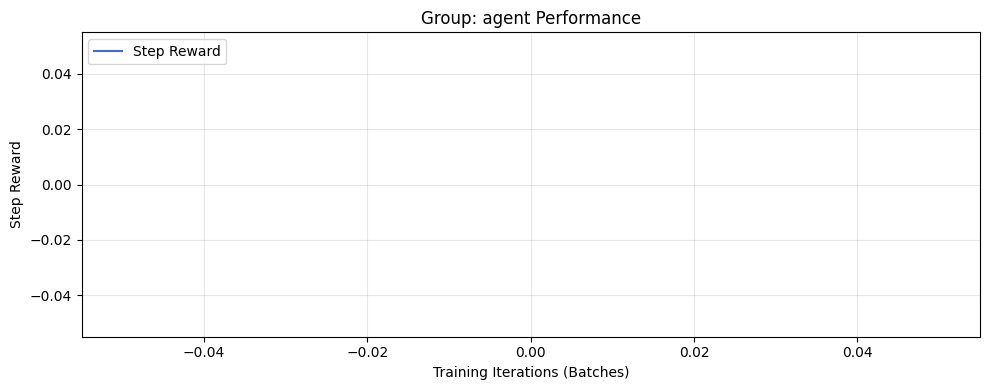

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Dynamically determine the number of rows based on your group map
num_groups = len(env.group_map.keys())
fig, axs = plt.subplots(num_groups, 1, figsize=(10, 4 * num_groups), sharex=True)

# 2. If there's only one group, matplotlib returns a single Axes object instead of an array
if num_groups == 1:
    axs = [axs]

for i, group in enumerate(env.group_map.keys()):
    # Get the raw step rewards
    data = np.array(reward_history_map[group])
    
    # 3. Calculate a rolling mean for smoother visualization
    # Window of 10 iterations is usually good for seeing trends
    window = 10
    if len(data) > window:
        smooth_data = np.convolve(data, np.ones(window)/window, mode='valid')
        # Plot raw data with transparency and smoothed data on top
        axs[i].plot(data, alpha=0.2, color='royalblue') 
        axs[i].plot(np.arange(window-1, len(data)), smooth_data, 
                    label=f"Rolling Mean (w={window})", color='darkblue', linewidth=2)
    else:
        axs[i].plot(data, label="Step Reward", color='royalblue')

    axs[i].set_title(f"Group: {group} Performance")
    axs[i].set_ylabel("Step Reward")
    axs[i].legend(loc="upper left")
    axs[i].grid(True, alpha=0.3)

# 4. Set the X-label only on the last subplot
axs[-1].set_xlabel("Training Iterations (Batches)")

plt.tight_layout()
plt.show()